# Bayes-Factor Trajectories Across Sample Size

This notebook plots how model evidence changes as more synthetic NK cells are included. The inference results are generated by `../script/run_2_bf_trajectory.sh`, with independent simulation replicates for each scenario and sample size.

For each synthetic scenario, the four candidate models are compared against the scenario's ground-truth model using

$$\log_{10}\mathrm{BF}(\mathcal{M}/\mathcal{M}_{\mathrm{true}}).$$

The ground-truth model is therefore the horizontal zero line. Values below zero mean the candidate model is disfavored relative to the true model; values above zero mean the candidate model has higher evidence than the true model for that finite sample. Lines show replicate means and error bars show replicate variability.

In [8]:
from __future__ import annotations

from pathlib import Path
from typing import Any, Dict, Optional, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import NullLocator

try:
    import scienceplots
    plt.style.use("science")
except ModuleNotFoundError:
    plt.style.use("default")


PROJECT_ROOT = next(
    p for p in [Path.cwd(), *Path.cwd().parents]
    if (p / "section_1" / "src" / "inference.py").exists()
)

RESULT_ROOT = PROJECT_ROOT / "section_1" / "results" / "part_2_bf_trajectory"
FIGURE_ROOT = PROJECT_ROOT / "section_1" / "figures" / "part_2_bf_trajectory"
FIGURE_ROOT.mkdir(parents=True, exist_ok=True)

LOGML_PATH = RESULT_ROOT / "logml_summary.csv"
logml_df = pd.read_csv(LOGML_PATH)
if "replicate" not in logml_df.columns:
    logml_df["replicate"] = 1

MODEL_ORDER = ["homo", "Z2P", "Dis2P", "hetero3"]
MODEL_DISPLAY = {
    "homo": "homo",
    "Z2P": "ZI",
    "Dis2P": r"$\Gamma$",
    "hetero3": r"ZI $\Gamma$",
}
MODEL_COLORS = {
    "homo": "#8EC7E8",
    "Z2P": "#3FA7D6",
    "Dis2P": "#1F78B4",
    "hetero3": "#08306B",
}
BAND_COLORS = {
    "anecdotal": "#F7F7F7",
    "moderate": "#FFF3B0",
    "strong": "#FFD28A",
    "extreme": "#E76F51",
}

SCENARIO_ORDER = ["No1", "No2", "No3", "No4"]

logml_df.head()

,scenario,scenario_label,replicate,simulation_seed,mu_lambda,sigma_lambda,p_zero,true_model,best_model,n_cells,model,logml,log10_bf_model_vs_true,log10_bf_model_vs_best
0,No1,"No1: sigma=3, p0=0.2",1,12027,4.0,3.0,0.2,hetero3,homo,10,homo,-22.571622,1.035533,0.000000
1,No1,"No1: sigma=3, p0=0.2",1,12027,4.0,3.0,0.2,hetero3,homo,10,Z2P,-23.971007,0.427787,-0.607745
2,No1,"No1: sigma=3, p0=0.2",1,12027,4.0,3.0,0.2,hetero3,homo,10,Dis2P,-23.292529,0.722447,-0.313086
3,No1,"No1: sigma=3, p0=0.2",1,12027,4.0,3.0,0.2,hetero3,homo,10,hetero3,-24.956024,0.000000,-1.035533
4,No1,"No1: sigma=3, p0=0.2",1,12027,4.0,3.0,0.2,hetero3,Dis2P,20,homo,-49.573324,-0.856131,-1.476479


## Plot Helpers

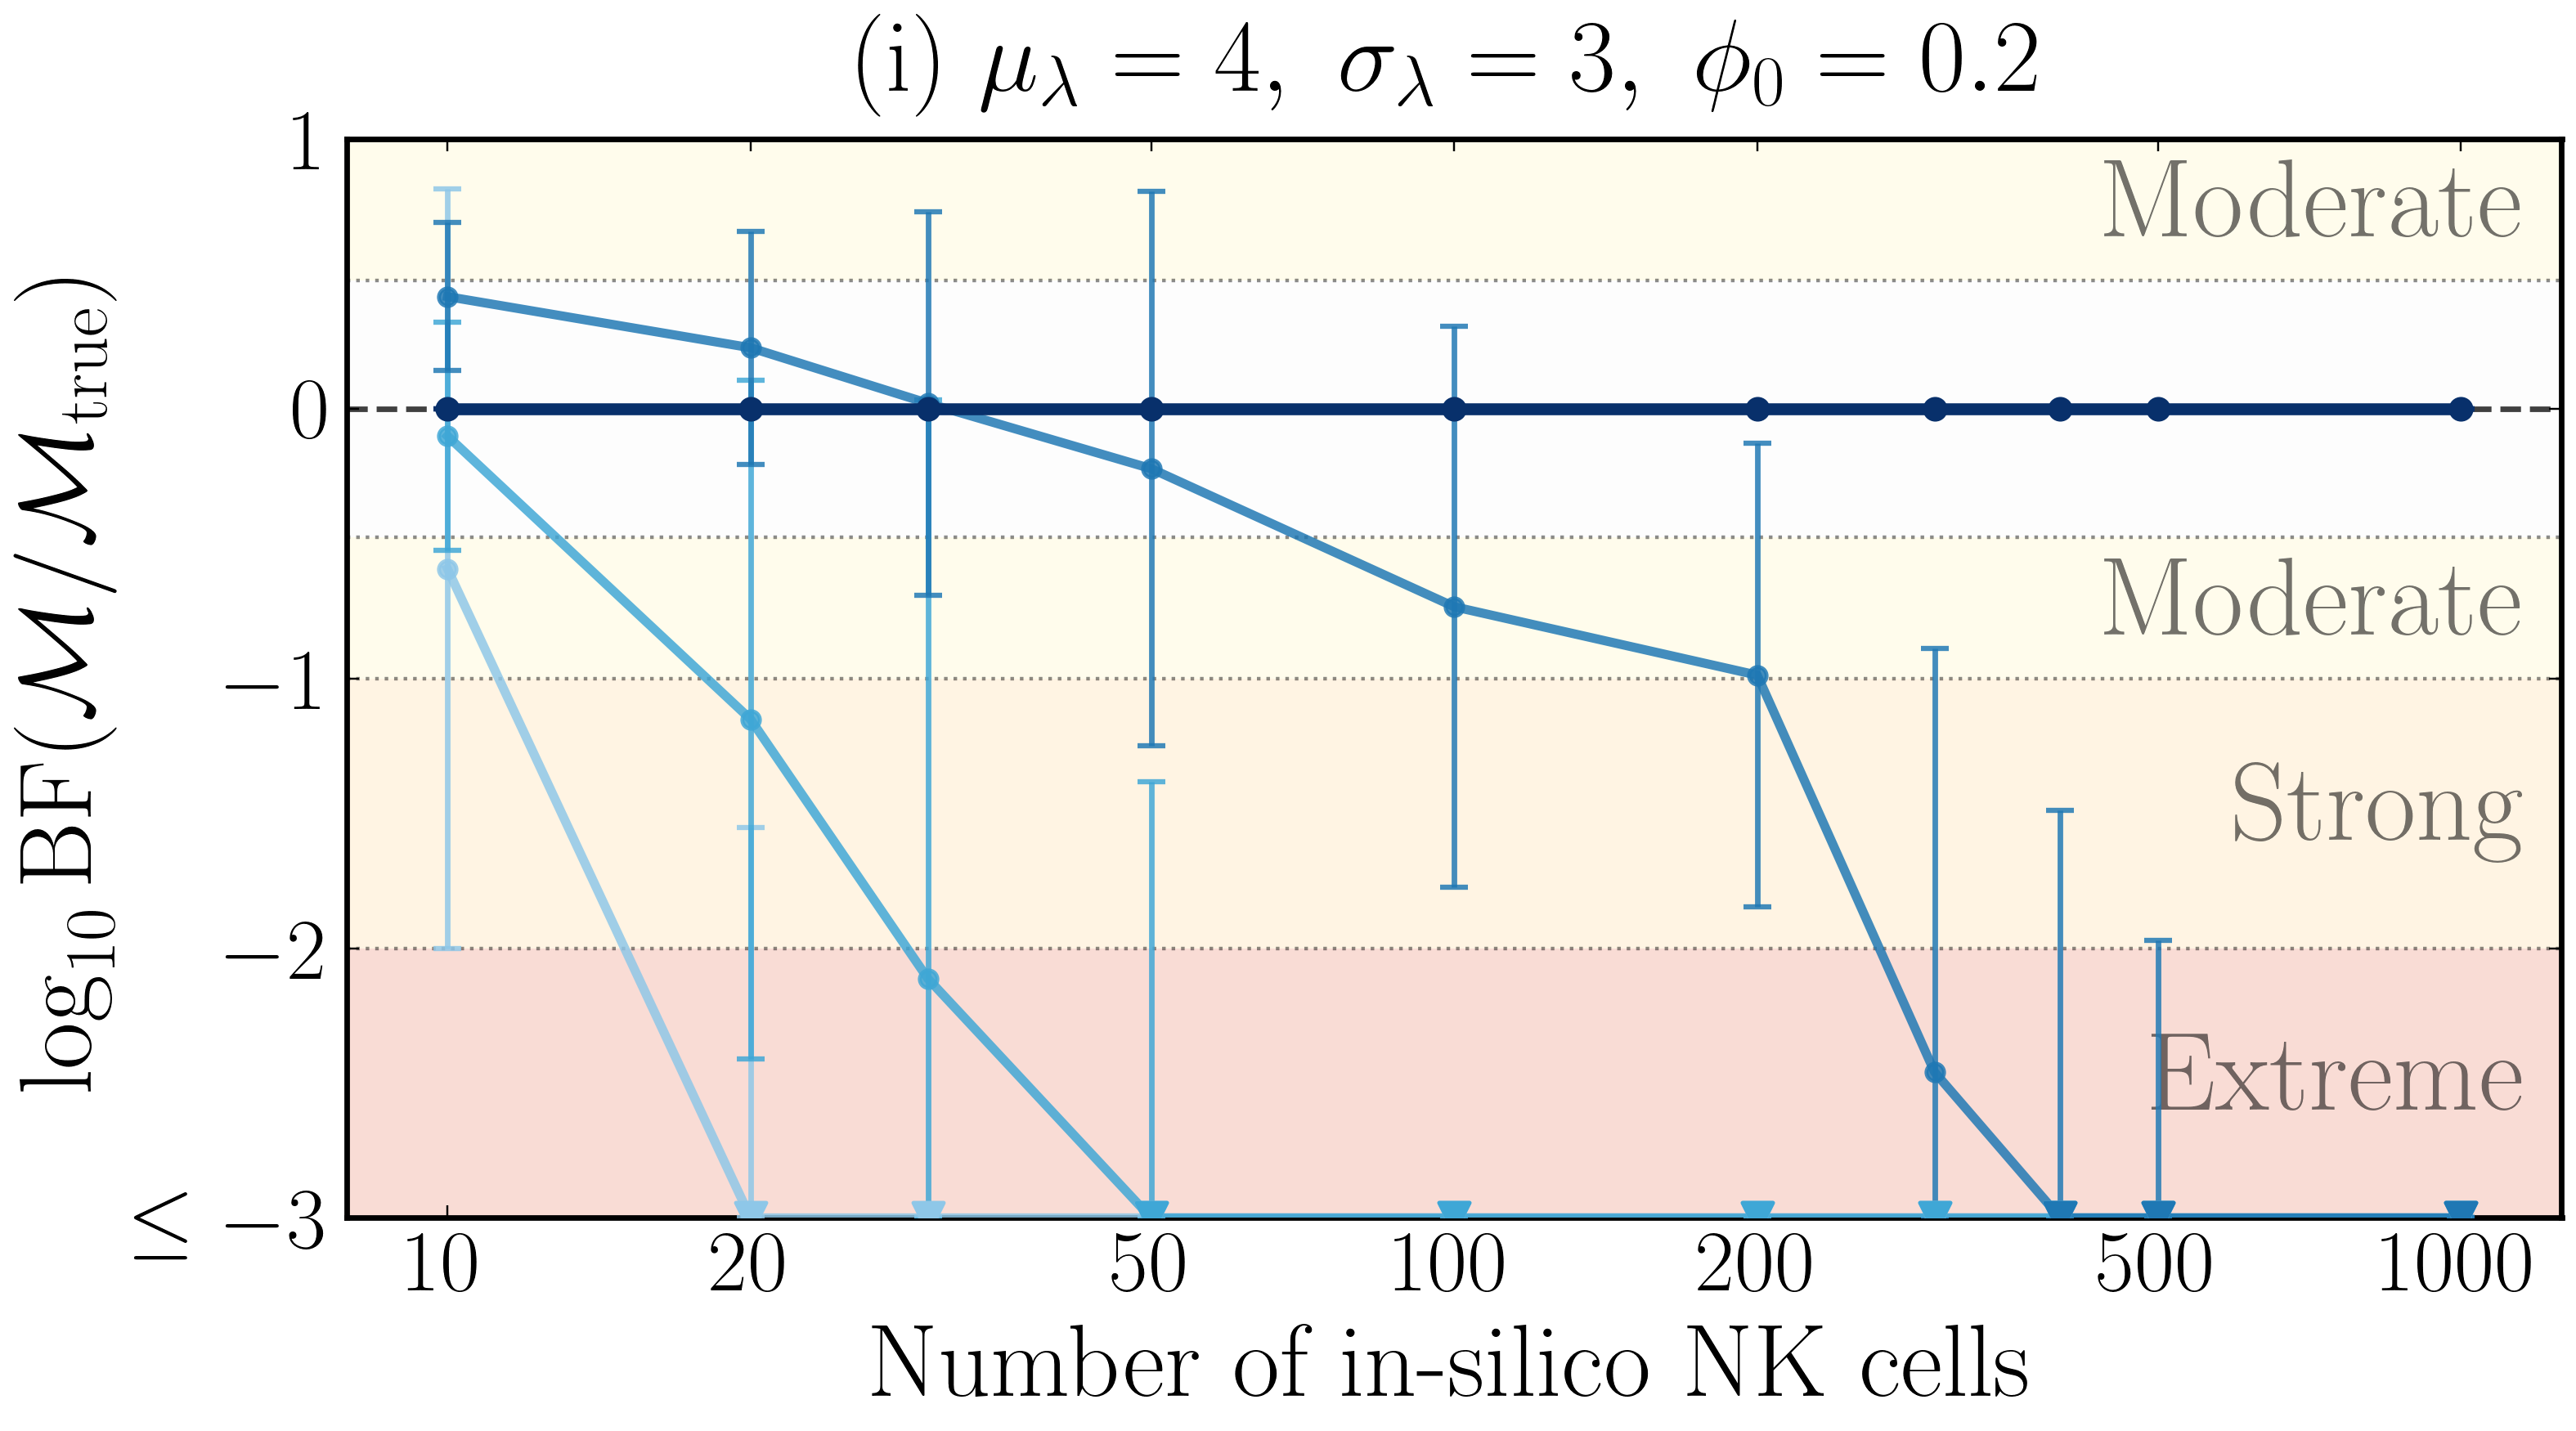

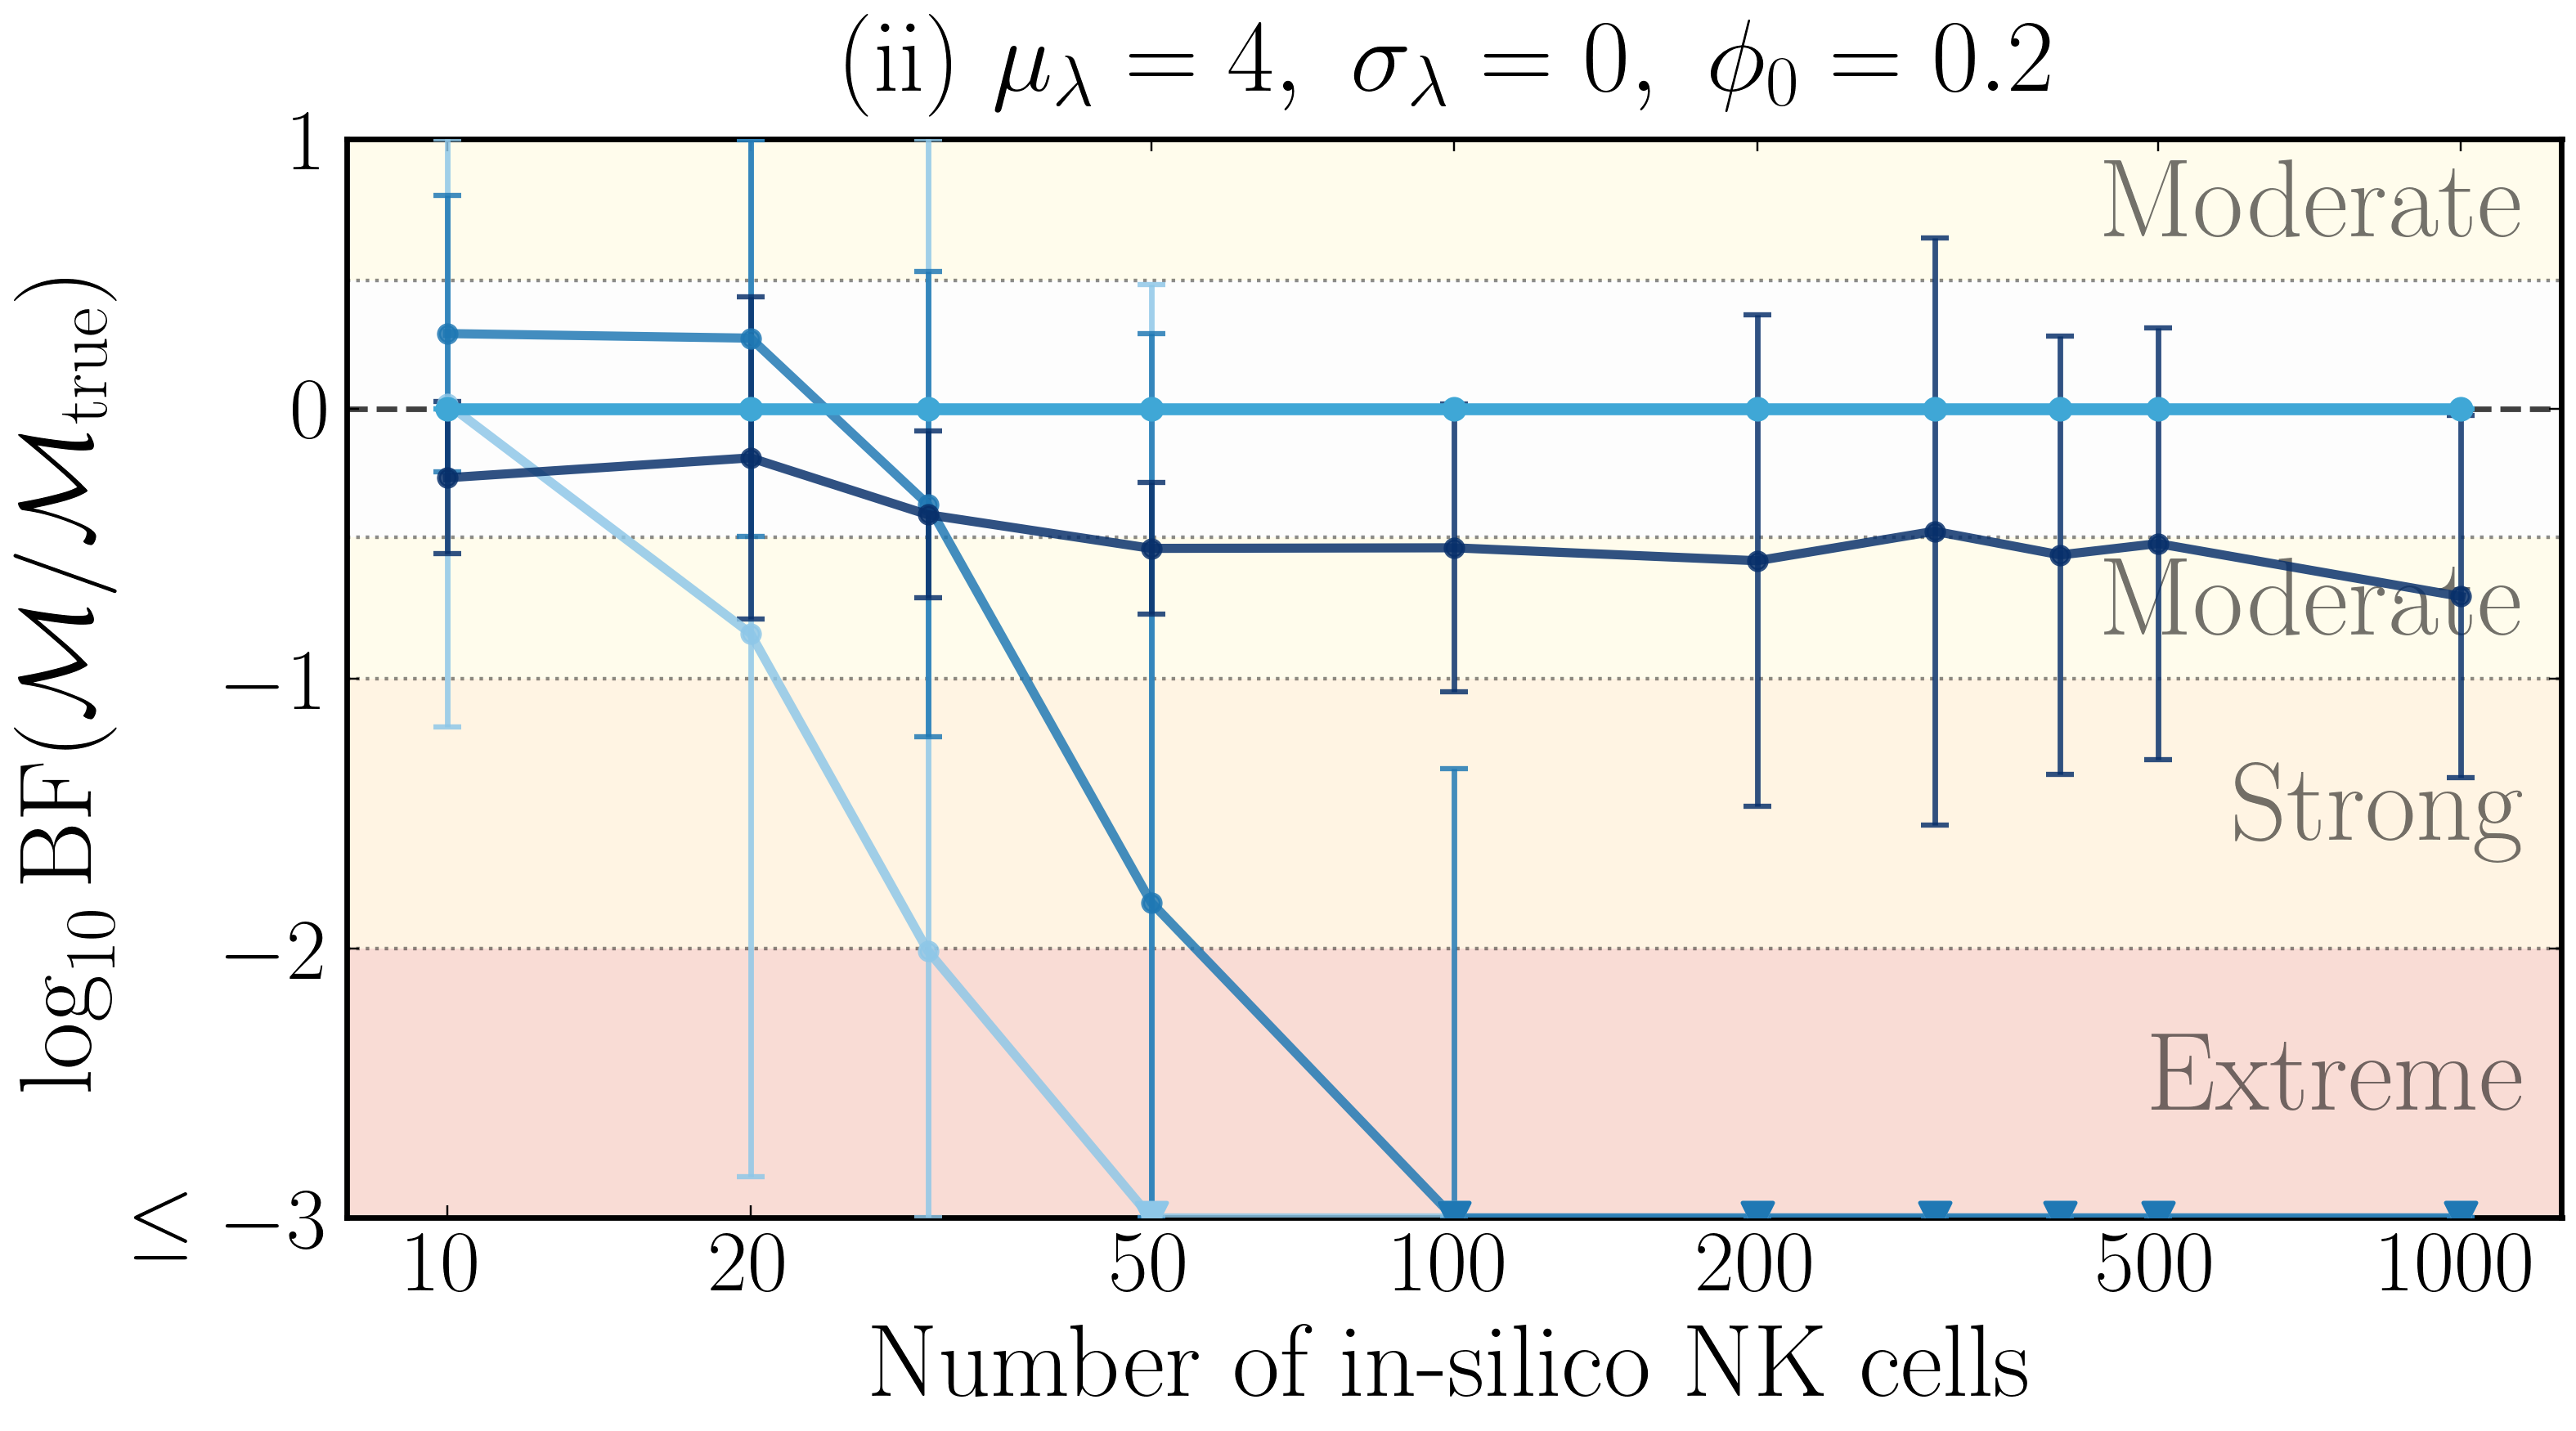

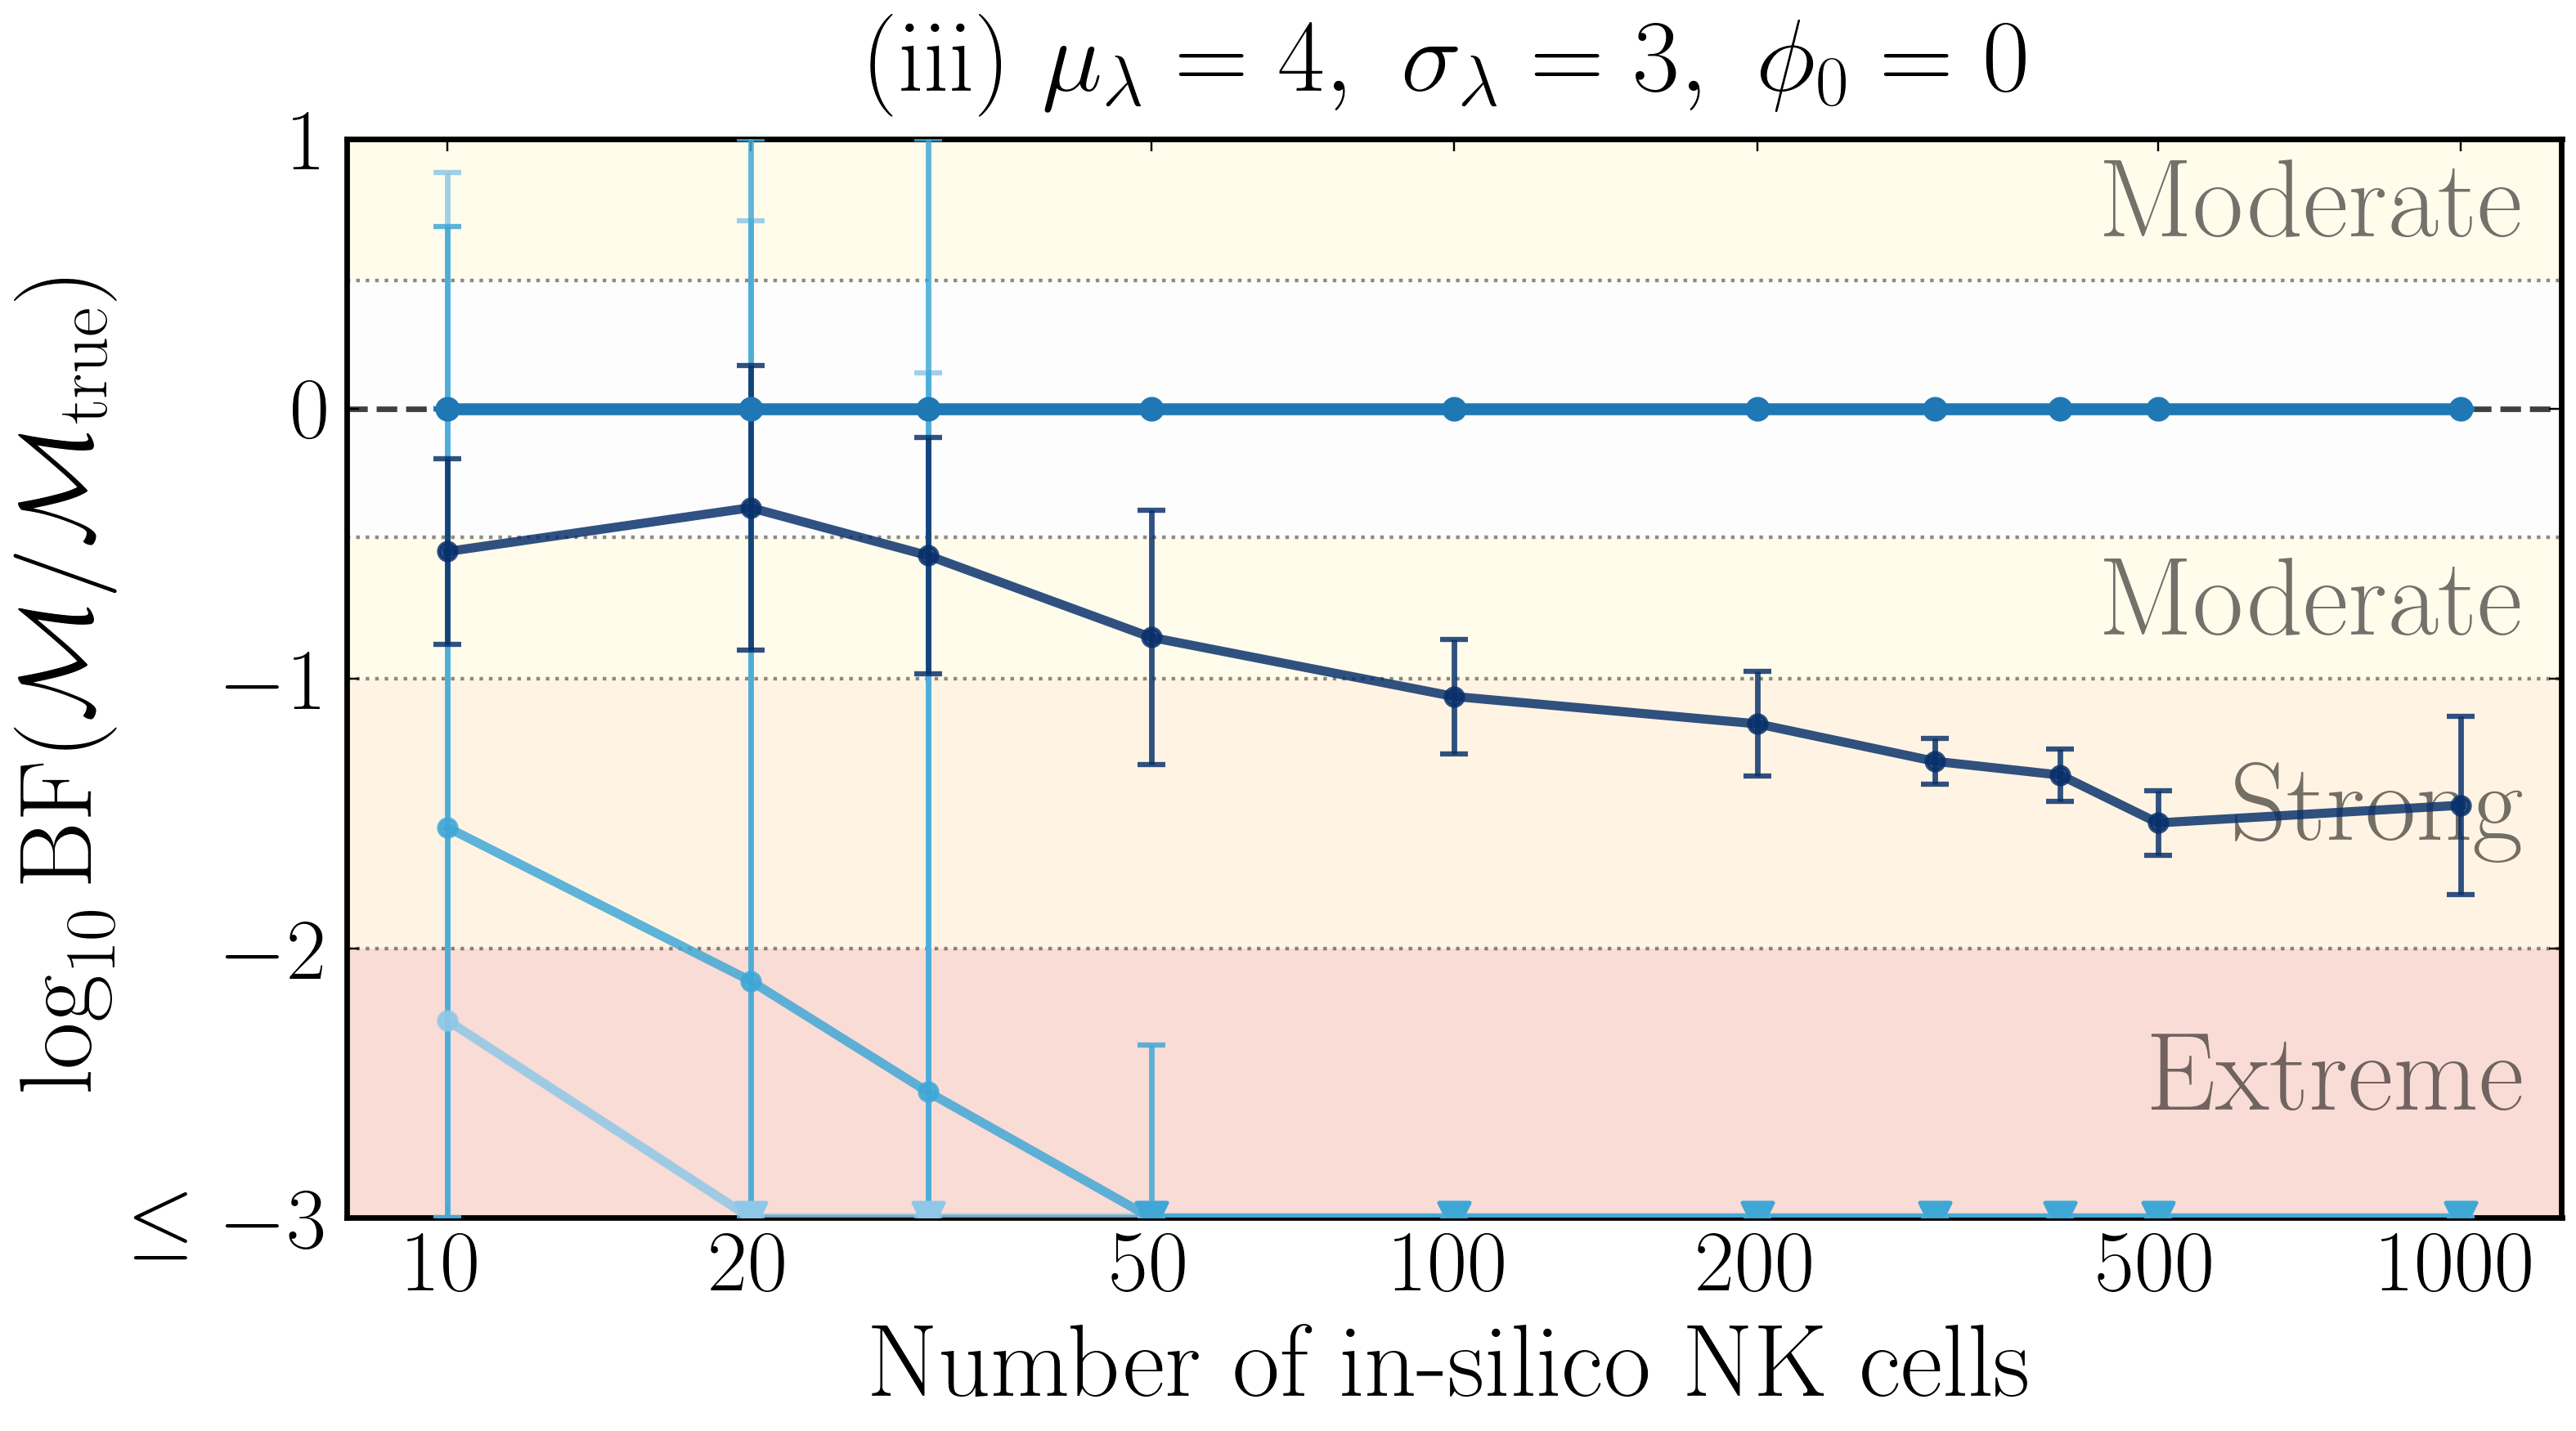

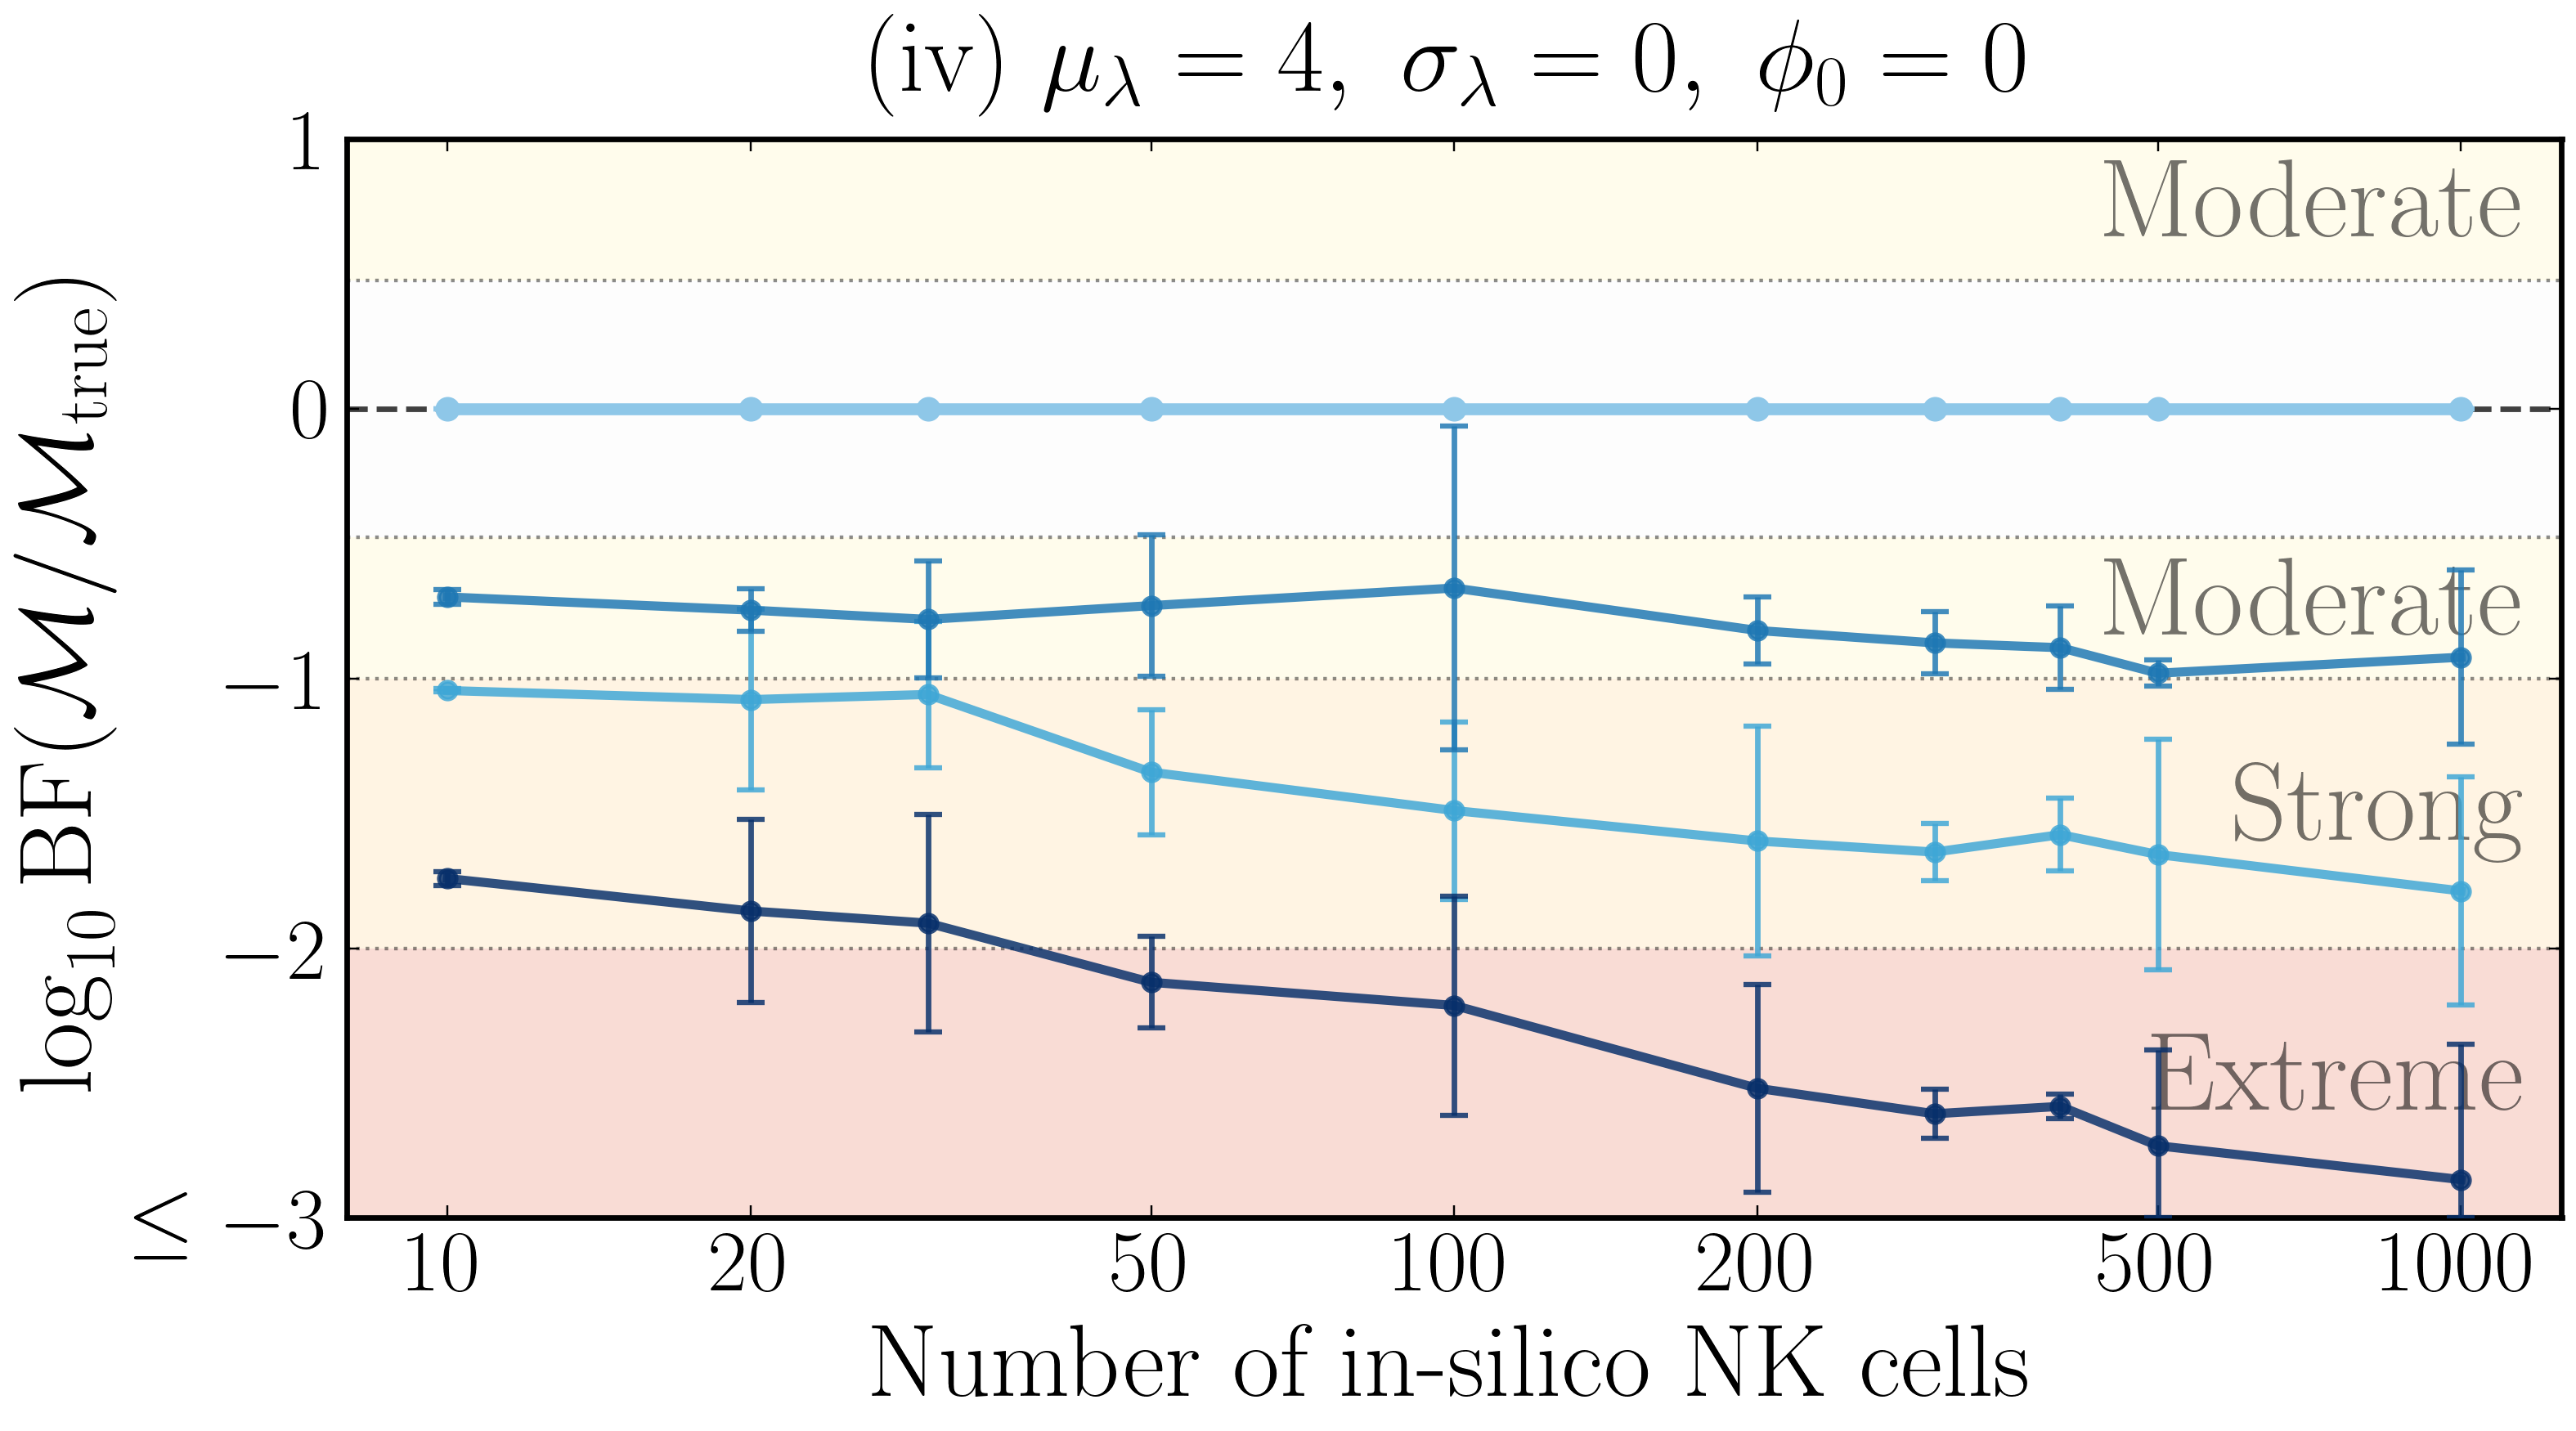

,svg
0,/Users/marsian/PhD_LifeSciRes/Orca/section_1/f...
1,/Users/marsian/PhD_LifeSciRes/Orca/section_1/f...
2,/Users/marsian/PhD_LifeSciRes/Orca/section_1/f...
3,/Users/marsian/PhD_LifeSciRes/Orca/section_1/f...


In [11]:
SCENARIO_ROMAN = {
    "No1": "i",
    "No2": "ii",
    "No3": "iii",
    "No4": "iv",
}

def scenario_title(row: pd.Series) -> str:
    scenario_label = SCENARIO_ROMAN.get(str(row["scenario"]), str(row["scenario"]))
    return (
        rf"({scenario_label}) "
        rf"$\mu_\lambda={float(row['mu_lambda']):g},\ "
        rf"\sigma_\lambda={float(row['sigma_lambda']):g},\ "
        rf"\phi_0={float(row['p_zero']):g}$"
    )


def _to_even_bf_axis(values: Sequence[float], *, clip_log10_bf: float = 3.0) -> np.ndarray:
    raw = np.asarray(values, dtype=float)
    sign = np.sign(raw)
    magnitude = np.abs(raw)

    bf3 = np.log10(3.0)
    bf10 = 1.0
    bf100 = 2.0
    clip_log10_bf = max(float(clip_log10_bf), bf100 + 1e-6)

    display_mag = np.zeros_like(magnitude, dtype=float)

    mask = magnitude <= bf3
    display_mag[mask] = magnitude[mask] / bf3

    mask = (magnitude > bf3) & (magnitude <= bf10)
    display_mag[mask] = 1.0 + (magnitude[mask] - bf3) / (bf10 - bf3)

    mask = (magnitude > bf10) & (magnitude <= bf100)
    display_mag[mask] = 2.0 + (magnitude[mask] - bf10) / (bf100 - bf10)

    mask = magnitude > bf100
    display_mag[mask] = 3.0 + np.minimum(
        (magnitude[mask] - bf100) / (clip_log10_bf - bf100),
        1.0,
    )

    return sign * display_mag


def add_bf_bands(
    ax,
    *,
    band_colors: dict[str, str] = BAND_COLORS,
    band_alpha: float = 0.24,
    label_bands: bool = True,
    band_label_size: int = 26,
    clip_log10_bf: float = 3.0,
    y_visible: tuple[float, float] | None = None,
) -> None:
    bf3 = np.log10(3.0)
    clip_log10_bf = max(float(clip_log10_bf), 2.0 + 1e-6)
    if y_visible is None:
        y_visible = (-clip_log10_bf, 1.0)
    ymin, ymax = y_visible

    bands = [
        ("extreme", -clip_log10_bf, -2.0),
        ("strong", -2.0, -1.0),
        ("moderate", -1.0, -bf3),
        ("anecdotal", -bf3, bf3),
        ("moderate", bf3, 1.0),
        ("strong", 1.0, 2.0),
        ("extreme", 2.0, clip_log10_bf),
    ]

    for label, low, high in bands:
        visible_low = max(low, ymin)
        visible_high = min(high, ymax)

        if visible_low >= visible_high:
            continue

        ax.axhspan(
            visible_low,
            visible_high,
            color=band_colors.get(label, "white"),
            alpha=band_alpha,
            linewidth=0,
            zorder=0,
        )

        # Keep the zero/anecdotal region clean.
        if label_bands and label != "anecdotal":
            ax.text(
                0.985,
                (visible_low + visible_high) / 2,
                label.capitalize(),
                transform=ax.get_yaxis_transform(),
                ha="right",
                va="center",
                fontsize=band_label_size,
                color="black",
                alpha=0.55,
                zorder=2,
                clip_on=True,
            )

    for y in [-2.0, -1.0, -bf3, 0.0, bf3, 1.0]:
        if ymin <= y <= ymax:
            ax.axhline(
                y,
                color="black",
                linestyle="--" if y == 0 else ":",
                linewidth=1.4 if y == 0 else 0.9,
                alpha=0.75 if y == 0 else 0.45,
                zorder=1,
            )


# def setup_banded_bf_axis(ax, *, clip_log10_bf: float = 3.0) -> None:
#     ax.set_ylim(-4.0, 1.0)

#     ax.set_yticks([-4, -3, -2, -1, 0, 1])
#     ax.set_yticklabels(
#         [
#             rf"$\leq -{clip_log10_bf:g}$",
#             r"$-2$",
#             r"$-1$",
#             r"$-\log_{10}3$",
#             "0",
#             r"$\log_{10}3$",
#         ]
#     )

def setup_banded_bf_axis(ax, *, clip_log10_bf: float = 3.0) -> None:
    upper = 1.0
    ax.set_ylim(-clip_log10_bf, upper)

    ax.set_yticks([
        -clip_log10_bf,
        -2,
        -1,
        # -np.log10(3.0),
        0,
        # np.log10(3.0),
        1,
    ])
    ax.set_yticklabels([
        rf"$\leq -{clip_log10_bf:g}$",
        r"$-2$",
        r"$-1$",
        # r"$-\log_{10}3$",
        "0",
        # r"$\log_{10}3$",
        "1",
    ])


def summarize_bf_replicates(
    model_df: pd.DataFrame,
    *,
    value_col: str = "log10_bf_model_vs_true",
    error_style: str = "sd",
) -> pd.DataFrame:
    summary = (
        model_df.groupby("n_cells", as_index=False)[value_col]
        .agg(mean="mean", sd="std", n_replicates="count")
        .sort_values("n_cells")
    )
    summary["sd"] = summary["sd"].fillna(0.0)

    if error_style == "sd":
        summary["err"] = summary["sd"]
    elif error_style == "sem":
        summary["err"] = summary["sd"] / np.sqrt(summary["n_replicates"].clip(lower=1))
    elif error_style in {"none", None}:
        summary["err"] = 0.0
    else:
        raise ValueError("error_style must be 'sd', 'sem', or 'none'.")

    return summary


def plot_bf_trajectory(
    scenario_id: str,
    *,
    ax=None,
    data: pd.DataFrame = logml_df,
    colors: dict[str, str] = MODEL_COLORS,
    band_colors: dict[str, str] = BAND_COLORS,
    band_alpha: float = 0.24,
    clip_log10_bf: float = 3.0,
    xscale: str = "log",
    show_legend: bool = False,
    title_size: int = 26,
    label_size: int = 26,
    tick_size: int = 22,
    legend_size: int = 22,
    band_label_size: int = 28,
    upper_label_size: int = 13,
    error_style: str = "sd",
    show_replicates: bool = False,
    replicate_alpha: float = 0.18,
    dpi: int = 350,
):
    created_fig = ax is None
    if ax is None:
        fig, ax = plt.subplots(figsize=(9.2, 5.2), dpi=dpi)
    else:
        fig = ax.figure

    sub = data[data["scenario"] == scenario_id].copy()
    if sub.empty:
        raise ValueError(f"No rows found for scenario {scenario_id!r}")

    info = sub.iloc[0]
    true_model = str(info["true_model"])
    y_upper = 1.0

    add_bf_bands(
        ax,
        band_colors=band_colors,
        band_alpha=band_alpha,
        label_bands=True,
        band_label_size=band_label_size,
        clip_log10_bf=clip_log10_bf,
    )

    for model in MODEL_ORDER:
        model_df = sub[sub["model"] == model].sort_values(["replicate", "n_cells"])
        if model_df.empty:
            continue

        is_true = model == true_model
        color = colors.get(model, "black")

        if show_replicates and "replicate" in model_df.columns:
            for _replicate, rep_df in model_df.groupby("replicate"):
                rep_x = rep_df["n_cells"].to_numpy(dtype=float)
                rep_raw = rep_df["log10_bf_model_vs_true"].to_numpy(dtype=float)
                # rep_y = np.clip(_to_even_bf_axis(rep_raw, clip_log10_bf=clip_log10_bf), -4.0, 1.0)
                rep_y = np.clip(rep_raw, -clip_log10_bf, y_upper)
                ax.plot(
                    rep_x,
                    rep_y,
                    color=color,
                    linewidth=1.0,
                    alpha=replicate_alpha,
                    zorder=2,
                )

        summary = summarize_bf_replicates(model_df, error_style=error_style)
        x = summary["n_cells"].to_numpy(dtype=float)
        raw_mean = summary["mean"].to_numpy(dtype=float)
        raw_err = summary["err"].to_numpy(dtype=float)

        raw_low = raw_mean - raw_err
        raw_high = raw_mean + raw_err
        # y = _to_even_bf_axis(raw_mean, clip_log10_bf=clip_log10_bf)
        y = np.clip(raw_mean, -clip_log10_bf, y_upper)
        # y_low = _to_even_bf_axis(raw_low, clip_log10_bf=clip_log10_bf)
        y_low = np.clip(raw_low, -clip_log10_bf, y_upper)
        # y_high = _to_even_bf_axis(raw_high, clip_log10_bf=clip_log10_bf)
        y_high = np.clip(raw_high, -clip_log10_bf, y_upper)

        y_plot = np.clip(y, -clip_log10_bf, y_upper)
        y_low_plot = np.clip(y_low, -clip_log10_bf, y_upper)
        y_high_plot = np.clip(y_high, -clip_log10_bf, y_upper)
        yerr = np.vstack(
            [
                np.maximum(y_plot - y_low_plot, 0.0),
                np.maximum(y_high_plot - y_plot, 0.0),
            ]
        )

        ax.errorbar(
            x,
            y_plot,
            yerr=yerr,
            color=color,
            linewidth=3.0 if is_true else 2.3,
            marker="o",
            markersize=5.2 if is_true else 4.4,
            capsize=3.5,
            elinewidth=1.4,
            capthick=1.3,
            alpha=1.0 if is_true else 0.84,
            label=f"{MODEL_DISPLAY.get(model, model)}" + (" (true)" if is_true else ""),
            zorder=4 if is_true else 3,
        )

        clipped_low = raw_mean < -clip_log10_bf
        if clipped_low.any():
            ax.scatter(
                x[clipped_low],
                # np.full(clipped_low.sum(), -4.0),
                np.full(clipped_low.sum(), -clip_log10_bf),
                marker="v",
                color=color,
                s=58,
                zorder=5,
            )

        above_visible = raw_mean > y_upper
        if above_visible.any():
            ax.scatter(
                x[above_visible],
                # np.full(above_visible.sum(), 1.0),
                np.full(above_visible.sum(), y_upper),
                marker="^",
                color=color,
                s=42,
                zorder=5,
            )

            for xx, raw_val in zip(x[above_visible], raw_mean[above_visible]):
                ax.text(
                    xx,
                    y_upper,
                    f"{raw_val:.1f}",
                    ha="center",
                    va="bottom",
                    fontsize=upper_label_size,
                    color=color,
                    rotation=45,
                    zorder=6,
                    clip_on=False,
                )

    ax.set_xscale(xscale)

    if xscale == "log":
        xticks = [10, 20, 50, 100, 200, 500, 1000]
        ax.set_xticks(xticks)
        ax.set_xticklabels([str(x) for x in xticks])

    ax.set_title(scenario_title(info), fontsize=title_size, pad=12)
    ax.set_xlabel("Number of in-silico NK cells", fontsize=label_size)
    ax.set_ylabel(
        r"$\log_{10}\mathrm{BF}(\mathcal{M}/\mathcal{M}_{\mathrm{true}})$",
        fontsize=label_size,
    )

    setup_banded_bf_axis(ax, clip_log10_bf=clip_log10_bf)

    ax.tick_params(axis="both", which="major", labelsize=tick_size)
    ax.xaxis.set_minor_locator(NullLocator())
    ax.yaxis.set_minor_locator(NullLocator())
    ax.minorticks_off()
    ax.grid(False)

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.4)
        spine.set_color("black")

    if show_legend:
        leg = ax.legend(
            frameon=True,
            edgecolor="black",
            fontsize=legend_size,
            loc="upper right",
        )
        leg.get_frame().set_alpha(1)

    if created_fig:
        fig.tight_layout()

    return fig, ax

single_figure_paths = []

for scenario_id in SCENARIO_ORDER:
    fig, ax = plot_bf_trajectory(
        scenario_id,
        colors=MODEL_COLORS,
        band_colors=BAND_COLORS,
        band_alpha=0.24,
        clip_log10_bf=3.0,
        xscale="log",
        legend_size=18,
    )
    out_path = FIGURE_ROOT / f"{scenario_id}_bf_trajectory_model_vs_true.svg"
    fig.savefig(out_path, bbox_inches="tight", transparent=True)
    plt.show()
    single_figure_paths.append(out_path)

pd.DataFrame({"svg": [str(path) for path in single_figure_paths]})